## Imports

In [1]:
import numpy as np
import pandas as pd
import torch

## Load data

In [2]:
import os

from google.colab import drive

drive.mount("/content/drive")

# Upload telemetry_train.csv, groundtruth_train.csv, telemetry_validation.csv,
# groundtruth_validation.csv into this Drive folder before running the next cell.
DATA_RAW_DIR = "/content/drive/MyDrive/DroneAcharaya/data/raw"
ARTIFACTS_DIR = "/content/drive/MyDrive/DroneAcharaya/ml_artifacts/lstm_rul"

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import gc

# Non-run_id/t/engine_state columns are numeric; loading them as float32 instead
# of pandas' float64 default roughly halves memory for a dataset this size.
_TELEMETRY_NON_NUMERIC = {"run_id", "engine_state", "engine_id", "mission_id", "data_origin"}
_GT_NON_NUMERIC = {"run_id", "sensor_fault_active_cht_c3"}


def _read_csv_f32(path, non_numeric_cols):
    header_cols = pd.read_csv(path, nrows=0).columns
    dtype_map = {c: "float32" for c in header_cols if c not in non_numeric_cols and c != "t"}
    return pd.read_csv(path, dtype=dtype_map)


telemetry_train_df = _read_csv_f32(f"{DATA_RAW_DIR}/telemetry_train.csv", _TELEMETRY_NON_NUMERIC)
gt_train_df = _read_csv_f32(f"{DATA_RAW_DIR}/groundtruth_train.csv", _GT_NON_NUMERIC)
telemetry_val_df = _read_csv_f32(f"{DATA_RAW_DIR}/telemetry_validation.csv", _TELEMETRY_NON_NUMERIC)
gt_val_df = _read_csv_f32(f"{DATA_RAW_DIR}/groundtruth_validation.csv", _GT_NON_NUMERIC)

# NOTE: this is the main_batch_1000 export, already split into train/validation
# by run_id — no random re-split needed. See train_mask below.
telemetry_df = pd.concat([telemetry_train_df, telemetry_val_df], ignore_index=True)
gt_df = pd.concat([gt_train_df, gt_val_df], ignore_index=True)
train_run_ids = set(telemetry_train_df["run_id"].unique())

# Free the four per-split frames now that they're concatenated — otherwise they
# stay alive (each a near-duplicate of telemetry_df/gt_df) and, combined with
# merged_df and the later one-hot concat, is what exceeds Colab's ~12.7GB RAM.
del telemetry_train_df, gt_train_df, telemetry_val_df, gt_val_df
gc.collect()

print(telemetry_df.shape, gt_df.shape)
print(telemetry_df.columns.tolist())
print(gt_df.columns.tolist())

(2569001, 40) (2569001, 48)
['run_id', 't', 'rpm', 'torque', 'power', 'engine_load', 'cht_c1', 'cht_c2', 'cht_c3', 'cht_c4', 'egt_c1', 'egt_c2', 'egt_c3', 'egt_c4', 'oil_pressure', 'oil_temperature', 'fuel_flow', 'rail_pressure', 'injection_timing', 'boost_pressure', 'map', 'intake_temperature', 'air_mass_flow', 'coolant_temperature', 'vibration_rms_x', 'vibration_order_1x', 'vibration_rms_x_bearing_proxy', 'vibration_order_1x_bearing_proxy', 'battery_voltage', 'battery_current', 'alternator_power', 'altitude', 'ambient_pressure', 'ambient_temperature', 'air_density', 'throttle', 'engine_state', 'engine_id', 'mission_id', 'data_origin']
['run_id', 't', 'rpm_true', 'torque_true', 'cht_c1_true', 'cht_c2_true', 'cht_c3_true', 'cht_c4_true', 'egt_c1_true', 'egt_c2_true', 'egt_c3_true', 'egt_c4_true', 'oil_pressure_true', 'oil_temperature_true', 'fuel_flow_true', 'rail_pressure_true', 'injection_timing_true', 'boost_pressure_true', 'map_true', 'intake_temperature_true', 'air_mass_flow_true'

## Merge

In [4]:
merged_df = pd.merge(
    telemetry_df,
    gt_df,
    on=["run_id", "t"],
    how="inner",
    validate="one_to_one",
)

assert len(merged_df) == len(telemetry_df), "Row count changed after merge — check join key alignment"

# telemetry_df/gt_df are now redundant with merged_df — free them before the
# next few cells build on merged_df.
del telemetry_df, gt_df
gc.collect()

print(merged_df.shape)

(2569001, 86)


## Column groups

In [5]:
# Matches data/raw/telemetry_{train,validation}.csv exactly (main_batch_1000).
# NOTE: this batch diverges from contract/telemetry-schema.yaml — missing
# fuel_quantity_used, fuel_remaining, injection_duration, turbo_speed,
# vibration_rms_y, vibration_rms_z, load_demand; adds vibration_rms_x_bearing_proxy
# and vibration_order_1x_bearing_proxy, which aren't in the frozen contract.
# The data generator needs a follow-up fix to align with the contract; until
# then, this list matches what's actually in data/raw/ so training can proceed.

SENSOR_COLUMNS = [
    "rpm",
    "torque",
    "power",
    "engine_load",
    "cht_c1",
    "cht_c2",
    "cht_c3",
    "cht_c4",
    "egt_c1",
    "egt_c2",
    "egt_c3",
    "egt_c4",
    "oil_pressure",
    "oil_temperature",
    "fuel_flow",
    "rail_pressure",
    "injection_timing",
    "boost_pressure",
    "map",
    "intake_temperature",
    "air_mass_flow",
    "coolant_temperature",
    "vibration_rms_x",
    "vibration_order_1x",
    "vibration_rms_x_bearing_proxy",
    "vibration_order_1x_bearing_proxy",
    "battery_voltage",
    "battery_current",
    "alternator_power",
    "altitude",
    "ambient_pressure",
    "ambient_temperature",
    "air_density",
    "throttle",
]

CATEGORICAL_COLUMNS = ["engine_state"]

HEALTH_1_TO_0_COLUMNS = [
    "injector_health_c1",
    "injector_health_c2",
    "injector_health_c3",
    "injector_health_c4",
    "cooling_health",
    "oil_pump_health",
    "bearing_health",
    "fuel_delivery_health",
    "alternator_health",
]
HEALTH_0_TO_1_COLUMNS = [
    "turbo_efficiency_deg",
    "injection_timing_deg",
    "combustion_stability",
    "misfire_rate_c1",
    "misfire_rate_c2",
    "misfire_rate_c3",
    "misfire_rate_c4",
]

# gt_df was freed after the merge (see Merge cell) — its columns all survive
# into merged_df, so detect sensor-fault columns from there instead.
SENSOR_FAULT_COLUMNS = [c for c in merged_df.columns if c.startswith("sensor_fault_active_")]
print("Detected sensor-fault columns:", SENSOR_FAULT_COLUMNS)

Detected sensor-fault columns: ['sensor_fault_active_cht_c3']


## Health sign flip

In [6]:
for col in HEALTH_0_TO_1_COLUMNS:
    merged_df[col] = 1.0 - merged_df[col]

HEALTH_ALL_COLUMNS = HEALTH_1_TO_0_COLUMNS + HEALTH_0_TO_1_COLUMNS
print(f"{len(HEALTH_ALL_COLUMNS)} health columns, all now 1.0=healthy -> 0.0=failed")

merged_df[HEALTH_ALL_COLUMNS].describe().T[["min", "max"]]

16 health columns, all now 1.0=healthy -> 0.0=failed


,min,max
injector_health_c1,0.4,1.0
injector_health_c2,0.4,1.0
injector_health_c3,0.4,1.0
injector_health_c4,0.4,1.0
cooling_health,0.5,1.0
oil_pump_health,0.5,1.0
bearing_health,0.5,1.0
fuel_delivery_health,0.4,1.0
alternator_health,0.5,1.0
turbo_efficiency_deg,0.3,1.0


## Failure thresholds

In [7]:
# Map each (now-flipped) health column to its failure threshold, converted into the
# same 1.0=healthy->0.0=failed direction as Cell 4.
#
# Original criteria from failure-mode-matrix.csv, converted:
#   injector_health_c{n} <= 0.6      -> already this direction, threshold = 0.6
#   oil_pump_health <= 0.5           -> threshold = 0.5
#   cooling_health <= 0.5            -> threshold = 0.5
#   turbo_efficiency_deg >= 0.7      -> flipped: 1-0.7 = 0.3
#   bearing_health <= 0.5            -> threshold = 0.5
#   misfire_rate >= 0.1              -> flipped: 1-0.1 = 0.9
#   combustion_stability >= 0.5      -> flipped: 1-0.5 = 0.5
#   fuel_delivery_health <= 0.6      -> threshold = 0.6
#   alternator_health <= 0.5         -> threshold = 0.5
#   injection_timing_deg >= 0.6      -> flipped: 1-0.6 = 0.4

FAILURE_THRESHOLDS = {
    "injector_health_c1": 0.6,
    "injector_health_c2": 0.6,
    "injector_health_c3": 0.6,
    "injector_health_c4": 0.6,
    "oil_pump_health": 0.5,
    "cooling_health": 0.5,
    "bearing_health": 0.5,
    "fuel_delivery_health": 0.6,
    "alternator_health": 0.5,
    "turbo_efficiency_deg": 0.3,  # flipped from >=0.7
    "injection_timing_deg": 0.4,  # flipped from >=0.6
    "combustion_stability": 0.5,  # flipped from >=0.5
    "misfire_rate_c1": 0.9,  # flipped from >=0.1
    "misfire_rate_c2": 0.9,
    "misfire_rate_c3": 0.9,
    "misfire_rate_c4": 0.9,
}

missing = set(HEALTH_ALL_COLUMNS) - set(FAILURE_THRESHOLDS)
assert not missing, f"Missing thresholds for: {missing}"

## RUL deviation

In [8]:
def compute_rul_for_run(run_df: pd.DataFrame) -> pd.Series:
    """
    For each timestep, RUL = time until the FIRST future crossing of any health
    parameter below its failure threshold. If a parameter never crosses within
    the run, it does not contribute (treated as right-censored / no failure event
    for that parameter in this run).
    """
    run_df = run_df.sort_values("t").reset_index(drop=True)
    t = run_df["t"].values
    n = len(run_df)
    rul = np.full(n, np.nan)

    # For each health column, find the first index where it crosses its threshold
    first_failure_times = []
    for col, thresh in FAILURE_THRESHOLDS.items():
        below = run_df[col].values <= thresh
        idx = np.argmax(below) if below.any() else -1
        if idx > 0 or (idx == 0 and below[0]):
            first_failure_times.append(t[idx])

    if len(first_failure_times) == 0:
        # No failure reached in this run — RUL = time remaining to end of run
        # (censored; flag separately if you want to exclude these from RUL loss)
        end_time = t[-1]
        rul = end_time - t
    else:
        nearest_failure_t = min(first_failure_times)
        rul = np.clip(nearest_failure_t - t, a_min=0, a_max=None)

    return pd.Series(rul, index=run_df.index)


rul_parts = []
for run_id, run_df in merged_df.groupby("run_id", sort=False):
    rul_series = compute_rul_for_run(run_df)
    rul_series.index = run_df.index
    rul_parts.append(rul_series)

merged_df["rul"] = pd.concat(rul_parts).sort_index()
merged_df[["run_id", "t", "rul"]].head(10)

,run_id,t,rul
0,UNIT-alternatordegradation-0100_M001,0,1635
1,UNIT-alternatordegradation-0100_M001,1,1634
2,UNIT-alternatordegradation-0100_M001,2,1633
3,UNIT-alternatordegradation-0100_M001,3,1632
4,UNIT-alternatordegradation-0100_M001,4,1631
5,UNIT-alternatordegradation-0100_M001,5,1630
6,UNIT-alternatordegradation-0100_M001,6,1629
7,UNIT-alternatordegradation-0100_M001,7,1628
8,UNIT-alternatordegradation-0100_M001,8,1627
9,UNIT-alternatordegradation-0100_M001,9,1626


## Sensor fault class mapping

In [9]:
SENSOR_FAULT_CLASSES = ["NONE", "BIAS", "DRIFT", "NOISE", "STUCK", "DROPOUT"]
sensor_fault_class_map = {c: i for i, c in enumerate(SENSOR_FAULT_CLASSES)}

for col in SENSOR_FAULT_COLUMNS:
    merged_df[col] = merged_df[col].map(sensor_fault_class_map)

merged_df[SENSOR_FAULT_COLUMNS].head()

,sensor_fault_active_cht_c3
0,0
1,0
2,0
3,0
4,0


## Train + val split + scaling

In [10]:
from sklearn.preprocessing import StandardScaler

# Uses the train/validation split already assigned by the main_batch_1000 export
# (train_run_ids, set in the load cell) rather than a random re-split.
train_mask = merged_df["run_id"].isin(train_run_ids)

# vibration_rms_x / vibration_order_1x are NaN in ~6% of rows — the crank-resolved
# vibration sidecar doesn't compute a value during IDLE/CRUISE/SHUTDOWN/STARTING/
# THROTTLE_TRANSIENT. Left as NaN, these poison the scaler fit and then every
# training window/loss that touches them (which is what produced the all-NaN
# epochs). Add a missing-flag per affected column before scaling so the model
# can distinguish "sensor didn't report" from "value is near the training mean"
# — that's real information, since idle/cruise genuinely run smoother.
NAN_PRONE_SENSOR_COLUMNS = ["vibration_rms_x", "vibration_order_1x"]
MISSING_FLAG_COLUMNS = [f"{col}_missing" for col in NAN_PRONE_SENSOR_COLUMNS]

for col, flag_col in zip(NAN_PRONE_SENSOR_COLUMNS, MISSING_FLAG_COLUMNS):
    merged_df[flag_col] = merged_df[col].isna().astype(np.float32)

scaler = StandardScaler()
scaler.fit(
    merged_df.loc[train_mask, SENSOR_COLUMNS]
)  # fit stats on training runs only (NaNs excluded per-column by sklearn)

merged_df[SENSOR_COLUMNS] = scaler.transform(merged_df[SENSOR_COLUMNS])

# Fill remaining NaNs with 0 — after standardization, 0 is exactly the training
# mean, i.e. a neutral value, and the _missing flag preserves the fact that this
# was originally absent rather than genuinely at the mean.
merged_df[NAN_PRONE_SENSOR_COLUMNS] = merged_df[NAN_PRONE_SENSOR_COLUMNS].fillna(0.0)

assert not merged_df[SENSOR_COLUMNS].isna().any().any(), "NaNs remain in SENSOR_COLUMNS after fill"

## Encoder

In [11]:
import joblib
from sklearn.preprocessing import OneHotEncoder

ENGINE_STATE_CATEGORIES = [
    "OFF",
    "STARTING",
    "IDLE",
    "TAKEOFF",
    "CLIMB",
    "CRUISE",
    "HIGH_ALTITUDE_CRUISE",
    "LOITER",
    "THROTTLE_TRANSIENT",
    "DESCENT",
    "SHUTDOWN",
    "FAULT",
]

engine_state_encoder = OneHotEncoder(
    categories=[ENGINE_STATE_CATEGORIES],
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.float32,
)

engine_state_encoder.fit(merged_df.loc[train_mask, ["engine_state"]])

engine_state_encoded = engine_state_encoder.transform(merged_df[["engine_state"]])
engine_state_col_names = engine_state_encoder.get_feature_names_out(["engine_state"]).tolist()

# Assign columns directly instead of pd.concat([merged_df, engine_state_df]),
# which would allocate a full second copy of merged_df just to add 11 columns
# — exactly the kind of transient spike that exceeds Colab's ~12.7GB RAM.
for i, col_name in enumerate(engine_state_col_names):
    merged_df[col_name] = engine_state_encoded[:, i]
del engine_state_encoded
gc.collect()

joblib.dump(engine_state_encoder, f"{ARTIFACTS_DIR}/engine_state_encoder.joblib")

print("engine_state columns:", engine_state_col_names)

engine_state columns: ['engine_state_OFF', 'engine_state_STARTING', 'engine_state_IDLE', 'engine_state_TAKEOFF', 'engine_state_CLIMB', 'engine_state_CRUISE', 'engine_state_HIGH_ALTITUDE_CRUISE', 'engine_state_LOITER', 'engine_state_THROTTLE_TRANSIENT', 'engine_state_DESCENT', 'engine_state_SHUTDOWN', 'engine_state_FAULT']


## FEATURE_COLUMNS

In [12]:
FEATURE_COLUMNS = SENSOR_COLUMNS + MISSING_FLAG_COLUMNS + engine_state_col_names
TARGET_HEALTH_COLUMNS = HEALTH_ALL_COLUMNS  # regression, Head A
TARGET_RUL_COLUMN = "rul"  # regression, Head B
TARGET_SENSOR_FAULT_COLUMNS = SENSOR_FAULT_COLUMNS  # classification, Head C

print(f"{len(FEATURE_COLUMNS)} input features")
print(f"{len(TARGET_HEALTH_COLUMNS)} health targets")
print(f"{len(TARGET_SENSOR_FAULT_COLUMNS)} sensor-fault targets")

48 input features
16 health targets
1 sensor-fault targets


## Build windows

In [13]:
def build_windows(df, feature_cols, health_cols, rul_col, sensor_fault_cols, seq_len=60, stride=1, forecast_horizon=0):
    X_list, y_health_list, y_rul_list, y_sensor_fault_list = [], [], [], []

    for run_id, run_df in df.groupby("run_id", sort=False):
        run_df = run_df.sort_values("t").reset_index(drop=True)
        n = len(run_df)
        if n < seq_len + forecast_horizon:
            continue

        feats = run_df[feature_cols].values
        health = run_df[health_cols].values
        rul = run_df[rul_col].values
        sensor_fault = run_df[sensor_fault_cols].values

        for start in range(0, n - seq_len - forecast_horizon + 1, stride):
            end = start + seq_len
            label_idx = end - 1 + forecast_horizon  # <- the actual change
            X_list.append(feats[start:end])
            y_health_list.append(health[label_idx])
            y_rul_list.append(rul[label_idx])
            y_sensor_fault_list.append(sensor_fault[label_idx])

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_health_list, dtype=np.float32),
        np.array(y_rul_list, dtype=np.float32),
        np.array(y_sensor_fault_list, dtype=np.int64),
    )


train_df = merged_df[train_mask]
val_df = merged_df[~train_mask]

# stride=10 (not 1): at stride=1 this produces ~1.9M overlapping windows and
# X_train alone is ~20GB as float32 — OOMs on a 16GB laptop and is risky even
# on Colab/Kaggle free-tier RAM. stride=10 still slides a window across every
# run (a new window every 10 timesteps ≈ every 10s at this export rate) while
# keeping X_train to a manageable ~2GB.
WINDOW_STRIDE = 10

X_train, y_health_train, y_rul_train, y_sensor_fault_train = build_windows(
    train_df,
    FEATURE_COLUMNS,
    TARGET_HEALTH_COLUMNS,
    TARGET_RUL_COLUMN,
    TARGET_SENSOR_FAULT_COLUMNS,
    seq_len=60,
    stride=WINDOW_STRIDE,
    forecast_horizon=60,  # <- new: 60s ahead at 1Hz, tune as needed
)
X_val, y_health_val, y_rul_val, y_sensor_fault_val = build_windows(
    val_df,
    FEATURE_COLUMNS,
    TARGET_HEALTH_COLUMNS,
    TARGET_RUL_COLUMN,
    TARGET_SENSOR_FAULT_COLUMNS,
    seq_len=60,
    stride=WINDOW_STRIDE,
    forecast_horizon=60,
)

# RUL is a raw scalar in seconds (up to ~7000s in this batch) while health/sensor
# -fault losses are naturally O(1) — left unnormalized, RUL's MSE runs in the
# hundreds of thousands and drowns out the other two heads' gradients entirely
# (confirmed: health head collapsed to predicting ~0.5 for everything). Scale
# RUL down to a comparable magnitude using a fixed, interpretable divisor (1
# hour), derived independent of the data so it's stable across batches/reruns.
RUL_SCALE_SECONDS = 3600.0
y_rul_train = y_rul_train / RUL_SCALE_SECONDS
y_rul_val = y_rul_val / RUL_SCALE_SECONDS

print("Train:", X_train.shape, y_health_train.shape, y_rul_train.shape, y_sensor_fault_train.shape)
print("Val:  ", X_val.shape, y_health_val.shape, y_rul_val.shape, y_sensor_fault_val.shape)
print(f"y_rul_train range after /{RUL_SCALE_SECONDS:.0f}s: [{y_rul_train.min():.3f}, {y_rul_train.max():.3f}]")

Train: (190467, 60, 48) (190467, 16) (190467,) (190467, 1)
Val:   (53697, 60, 48) (53697, 16) (53697,) (53697, 1)
y_rul_train range after /3600s: [0.000, 1.910]


## Sanity checks

In [14]:
# Health values should be in [0,1] after the sign-flip in Cell 4
assert np.nanmin(y_health_train) >= -1e-3 and np.nanmax(y_health_train) <= 1.0 + 1e-3

# RUL should be non-negative (still true after the /RUL_SCALE_SECONDS normalization)
assert np.nanmin(y_rul_train) >= 0

# Sensor-fault class ids should be within range
assert y_sensor_fault_train.min() >= 0 and y_sensor_fault_train.max() < len(SENSOR_FAULT_CLASSES)

print("All sanity checks passed.")

All sanity checks passed.


## LSTM training

In [15]:
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
class EngineDataset(Dataset):
    def __init__(self, X, y_health, y_rul, y_sensor_fault):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_health = torch.tensor(y_health, dtype=torch.float32)
        self.y_rul = torch.tensor(y_rul, dtype=torch.float32)
        self.y_sensor_fault = torch.tensor(y_sensor_fault, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_health[idx], self.y_rul[idx], self.y_sensor_fault[idx]


train_dataset = EngineDataset(X_train, y_health_train, y_rul_train, y_sensor_fault_train)
val_dataset = EngineDataset(X_val, y_health_val, y_rul_val, y_sensor_fault_val)

# batch_size=128 (not 32): a T4/P100 GPU is under-utilized by small batches on a
# model this size — larger batches mean fewer, bigger matmuls and much better
# throughput. Drop back to 32 if training on CPU-only.
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} windows | Val: {len(val_dataset)} windows")

Train: 190467 windows | Val: 53697 windows


In [17]:
class EngineMultiHeadLSTM(nn.Module):
    def __init__(
        self,
        input_size,  # 47 = 34 sensors + 2 missing-flags + 11 engine_state one-hot (main_batch_1000)
        num_health_params,  # 16
        num_sensor_channels,  # len(SENSOR_FAULT_COLUMNS)
        num_sensor_fault_classes=6,  # NONE/BIAS/DRIFT/NOISE/STUCK/DROPOUT
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        bidirectional=False,  # unidirectional by default — see causality note below
    ):
        super().__init__()
        self.num_sensor_channels = num_sensor_channels
        self.num_sensor_fault_classes = num_sensor_fault_classes
        direction_factor = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        # attention pooling over timesteps instead of just the last one
        self.attn_fc = nn.Linear(hidden_size * direction_factor, 1)

        shared_dim = hidden_size * direction_factor
        self.shared_fc = nn.Sequential(
            nn.Linear(shared_dim, shared_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Head A: health-parameter regression (16 values, all 1.0=healthy -> 0.0=failed)
        self.health_head = nn.Sequential(
            nn.Linear(shared_dim // 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_health_params),
            nn.Sigmoid(),  # keep predictions in [0,1] to match the label convention
        )

        # Head B: RUL regression (single scalar, non-negative)
        self.rul_head = nn.Sequential(
            nn.Linear(shared_dim // 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

        # Head C: per-channel sensor-fault classification
        # outputs (num_sensor_channels * num_sensor_fault_classes) logits, reshaped
        self.sensor_fault_head = nn.Sequential(
            nn.Linear(shared_dim // 2, 128),
            nn.ReLU(),
            nn.Linear(128, num_sensor_channels * num_sensor_fault_classes),
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden*dir)

        attn_scores = self.attn_fc(lstm_out)  # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_scores, dim=1)  # (batch, seq_len, 1)
        context = torch.sum(attn_weights * lstm_out, dim=1)  # (batch, hidden*dir)

        shared = self.shared_fc(context)

        health_pred = self.health_head(shared)  # (batch, 16)
        rul_pred = nn.functional.softplus(self.rul_head(shared)).squeeze(-1)  # (batch,), >= 0
        sensor_fault_logits = self.sensor_fault_head(shared)
        sensor_fault_logits = sensor_fault_logits.view(
            -1, self.num_sensor_channels, self.num_sensor_fault_classes
        )  # (batch, num_channels, num_classes)

        return health_pred, rul_pred, sensor_fault_logits, attn_weights

In [18]:
def joint_loss(
    health_pred, health_true, rul_pred, rul_true, sensor_fault_logits, sensor_fault_true, alpha=1.0, beta=1.0, gamma=1.0
):
    health_loss = nn.functional.mse_loss(health_pred, health_true)
    rul_loss = nn.functional.mse_loss(rul_pred, rul_true)

    # cross-entropy per channel, then averaged — reshape to (batch*channels, classes) vs (batch*channels,)
    batch, num_channels, num_classes = sensor_fault_logits.shape
    sensor_fault_loss = nn.functional.cross_entropy(
        sensor_fault_logits.reshape(-1, num_classes),
        sensor_fault_true.reshape(-1),
    )

    total = alpha * health_loss + beta * rul_loss + gamma * sensor_fault_loss
    return total, health_loss.item(), rul_loss.item(), sensor_fault_loss.item()

In [19]:
def run_epoch(model, loader, optimizer=None, alpha=1.0, beta=1.0, gamma=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    totals = {"loss": 0.0, "health": 0.0, "rul": 0.0, "sensor_fault": 0.0}

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for X, y_health, y_rul, y_sensor_fault in loader:
            X = X.to(device)
            y_health = y_health.to(device)
            y_rul = y_rul.to(device)
            y_sensor_fault = y_sensor_fault.to(device)

            if is_train:
                optimizer.zero_grad()

            health_pred, rul_pred, sensor_fault_logits, _ = model(X)
            loss, h_l, r_l, sf_l = joint_loss(
                health_pred, y_health, rul_pred, y_rul, sensor_fault_logits, y_sensor_fault, alpha, beta, gamma
            )

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            totals["loss"] += loss.item()
            totals["health"] += h_l
            totals["rul"] += r_l
            totals["sensor_fault"] += sf_l

    n = len(loader)
    return {k: v / n for k, v in totals.items()}

In [20]:
NUM_HEALTH_PARAMS = len(TARGET_HEALTH_COLUMNS)  # 16
NUM_SENSOR_CHANNELS = len(SENSOR_FAULT_COLUMNS)
NUM_SENSOR_FAULT_CLASSES = 6  # NONE/BIAS/DRIFT/NOISE/STUCK/DROPOUT
INPUT_SIZE = X_train.shape[2]  # 47 = 34 sensors + 2 missing-flags + 11 engine_state one-hot (main_batch_1000)

model = EngineMultiHeadLSTM(
    input_size=INPUT_SIZE,
    num_health_params=NUM_HEALTH_PARAMS,
    num_sensor_channels=NUM_SENSOR_CHANNELS,
    num_sensor_fault_classes=NUM_SENSOR_FAULT_CLASSES,
    hidden_size=128,
    num_layers=2,
    bidirectional=False,  # causal — see note below before flipping this
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print(model)

EngineMultiHeadLSTM(
  (lstm): LSTM(48, 128, num_layers=2, batch_first=True, dropout=0.3)
  (attn_fc): Linear(in_features=128, out_features=1, bias=True)
  (shared_fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (health_head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): Sigmoid()
  )
  (rul_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (sensor_fault_head): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [21]:
import json

NUM_EPOCHS = 30
best_val_loss = float("inf")
LSTM_CHECKPOINT_PATH = f"{ARTIFACTS_DIR}/lstm_best.pt"

train_losses = []
val_losses = []
train_health_losses = []
val_health_losses = []
train_rul_losses = []
val_rul_losses = []
train_sf_losses = []
val_sf_losses = []

for epoch in range(NUM_EPOCHS):
    train_metrics = run_epoch(model, train_loader, optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_health_losses.append(train_metrics['health'])
    val_health_losses.append(val_metrics['health'])
    train_rul_losses.append(train_metrics['rul'])
    val_rul_losses.append(val_metrics['rul'])
    train_sf_losses.append(train_metrics['sensor_fault'])
    val_sf_losses.append(val_metrics['sensor_fault'])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        torch.save(model.state_dict(), LSTM_CHECKPOINT_PATH)

    print(
        f"Epoch {epoch + 1:2d} | "
        f"train_loss={train_metrics['loss']:.4f} "
        f"(h={train_metrics['health']:.4f}, r={train_metrics['rul']:.4f}, sf={train_metrics['sensor_fault']:.4f}) | "
        f"val_loss={val_metrics['loss']:.4f} "
        f"(h={val_metrics['health']:.4f}, r={val_metrics['rul']:.4f}, sf={val_metrics['sensor_fault']:.4f})"
    )

print(f"\nBest val loss: {best_val_loss:.4f} (checkpoint saved to {LSTM_CHECKPOINT_PATH})")

# RUL_SCALE_SECONDS must travel with the checkpoint — any later inference needs
# it to convert the model's normalized RUL output back into seconds.
with open(f"{ARTIFACTS_DIR}/rul_scale_seconds.json", "w") as f:
    json.dump({"rul_scale_seconds": RUL_SCALE_SECONDS}, f)

Epoch  1 | train_loss=0.1058 (h=0.0135, r=0.0780, sf=0.0143) | val_loss=0.4542 (h=0.0134, r=0.0439, sf=0.3969)
Epoch  2 | train_loss=0.0545 (h=0.0083, r=0.0462, sf=0.0000) | val_loss=0.7010 (h=0.0096, r=0.0349, sf=0.6564)
Epoch  3 | train_loss=0.0442 (h=0.0060, r=0.0382, sf=0.0000) | val_loss=0.5979 (h=0.0066, r=0.0382, sf=0.5531)
Epoch  4 | train_loss=0.0362 (h=0.0043, r=0.0319, sf=0.0000) | val_loss=0.5178 (h=0.0055, r=0.0422, sf=0.4701)
Epoch  5 | train_loss=0.0342 (h=0.0039, r=0.0303, sf=0.0000) | val_loss=0.4709 (h=0.0056, r=0.0384, sf=0.4269)
Epoch  6 | train_loss=0.0283 (h=0.0035, r=0.0247, sf=0.0000) | val_loss=0.3997 (h=0.0053, r=0.0373, sf=0.3572)
Epoch  7 | train_loss=0.0251 (h=0.0033, r=0.0218, sf=0.0000) | val_loss=0.3655 (h=0.0048, r=0.0318, sf=0.3288)
Epoch  8 | train_loss=0.0246 (h=0.0031, r=0.0215, sf=0.0000) | val_loss=0.3660 (h=0.0049, r=0.0440, sf=0.3171)
Epoch  9 | train_loss=0.0220 (h=0.0029, r=0.0191, sf=0.0000) | val_loss=0.3063 (h=0.0046, r=0.0425, sf=0.2593)
E

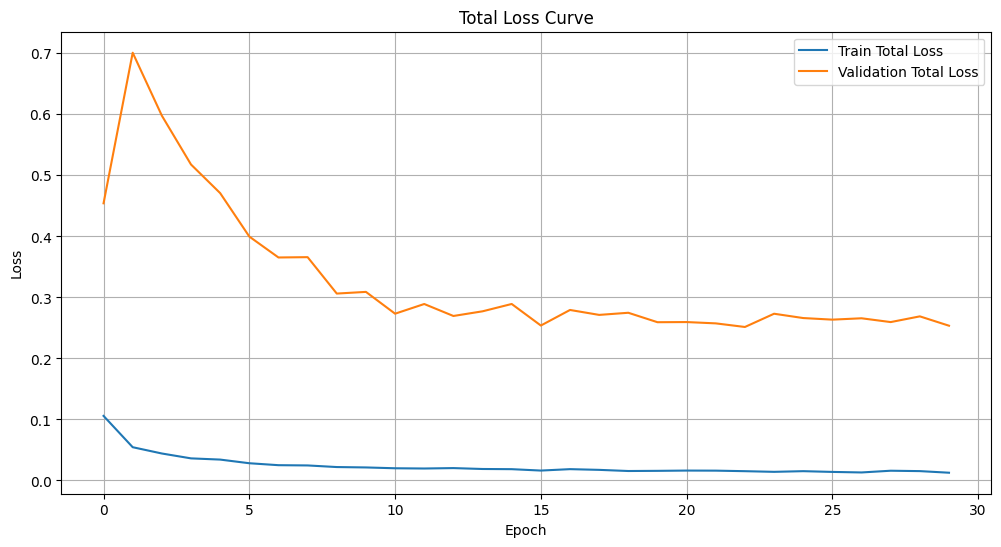

In [22]:
import matplotlib.pyplot as plt

# Plot Total Loss
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Total Loss')
plt.plot(val_losses, label='Validation Total Loss')
plt.title('Total Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

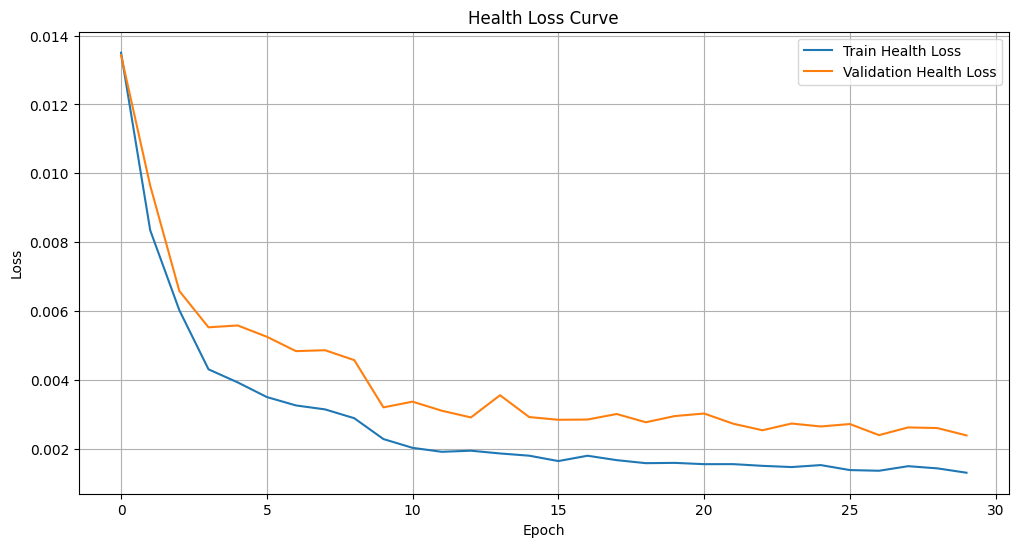

In [23]:
# Plot Health Loss
plt.figure(figsize=(12, 6))
plt.plot(train_health_losses, label='Train Health Loss')
plt.plot(val_health_losses, label='Validation Health Loss')
plt.title('Health Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

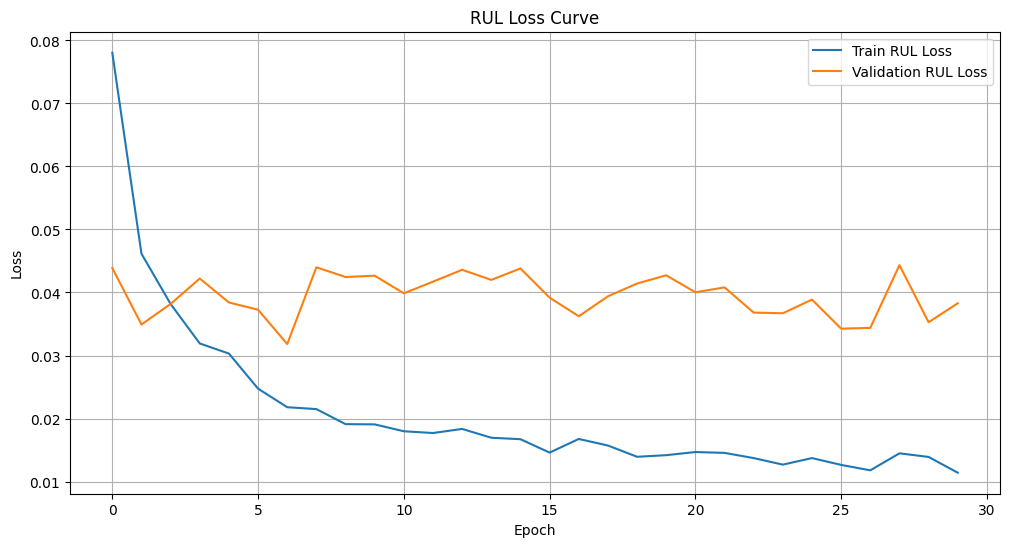

In [24]:
# Plot RUL Loss
plt.figure(figsize=(12, 6))
plt.plot(train_rul_losses, label='Train RUL Loss')
plt.plot(val_rul_losses, label='Validation RUL Loss')
plt.title('RUL Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

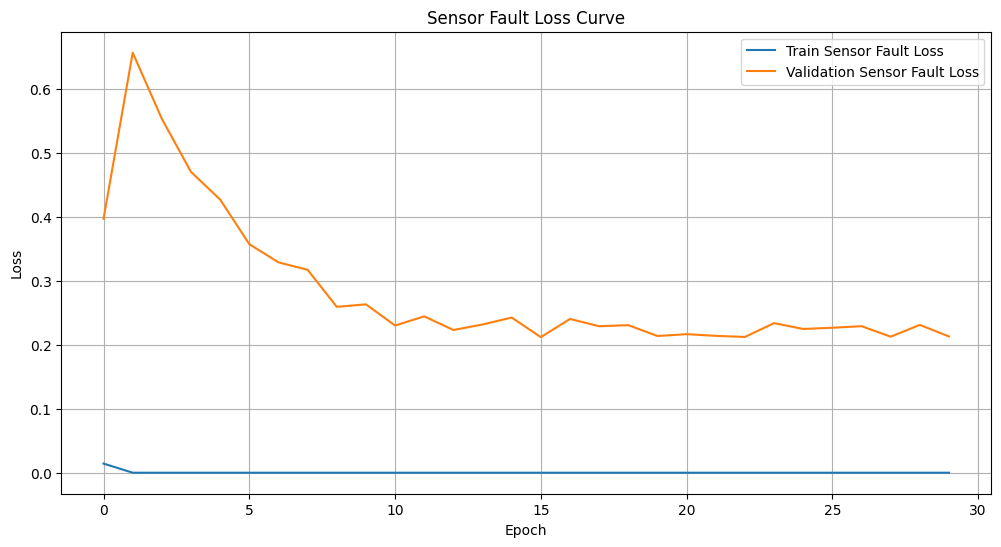

In [25]:
# Plot Sensor Fault Loss
plt.figure(figsize=(12, 6))
plt.plot(train_sf_losses, label='Train Sensor Fault Loss')
plt.plot(val_sf_losses, label='Validation Sensor Fault Loss')
plt.title('Sensor Fault Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
model.load_state_dict(torch.load(LSTM_CHECKPOINT_PATH))
model.eval()

with torch.no_grad():
    X_sample, y_health_sample, y_rul_sample, y_sf_sample = next(iter(val_loader))
    X_sample = X_sample.to(device)

    health_pred, rul_pred, sensor_fault_logits, _ = model(X_sample)
    sensor_fault_pred = sensor_fault_logits.argmax(dim=-1)

    # Undo the /RUL_SCALE_SECONDS normalization so predictions read in seconds,
    # matching the original (unscaled) ground truth in data/raw.
    rul_pred_seconds = rul_pred * RUL_SCALE_SECONDS
    y_rul_sample_seconds = y_rul_sample * RUL_SCALE_SECONDS

    print("Predicted RUL, seconds (first 5):", rul_pred_seconds[:5].cpu().numpy())
    print("True RUL, seconds (first 5):     ", y_rul_sample_seconds[:5].numpy())
    print("\nPredicted health[0] (first sample):", health_pred[0].cpu().numpy())
    print("True health[0] (first sample):     ", y_health_sample[0].numpy())

Predicted RUL, seconds (first 5): [37.77021  26.322145 15.372555 11.539906 10.210943]
True RUL, seconds (first 5):      [0. 0. 0. 0. 0.]

Predicted health[0] (first sample): [0.99999225 0.99516284 0.99998426 1.         0.98475075 0.9896813
 0.9999995  0.9999856  0.5006344  1.         0.9999442  0.99997973
 0.9930534  0.9997434  0.9998908  0.999992  ]
True health[0] (first sample):      [1.  1.  1.  1.  1.  1.  1.  1.  0.5 1.  1.  1.  1.  1.  1.  1. ]


In [27]:
# ---- Find validation indices with non-zero true RUL ----
import numpy as np

nonzero_idx = np.where(y_rul_val > 0)[0]
print(f"{len(nonzero_idx)} / {len(y_rul_val)} validation windows have RUL > 0 ({len(nonzero_idx) / len(y_rul_val):.1%})")

# Convert back to seconds for readability, then show a spread across the range
true_rul_seconds_all = y_rul_val[nonzero_idx] * RUL_SCALE_SECONDS
order = np.argsort(true_rul_seconds_all)
sorted_idx = nonzero_idx[order]
sorted_rul = true_rul_seconds_all[order]

# Sample 10 indices spread across the non-zero RUL range (low to high)
sample_positions = np.linspace(0, len(sorted_idx) - 1, 10).astype(int)
print("\nSuggested SAMPLE_IDX values (spread across RUL range):")
for pos in sample_positions:
    idx = sorted_idx[pos]
    print(f"  SAMPLE_IDX = {idx:6d}   true RUL = {sorted_rul[pos]:8.1f} s")


10973 / 53697 validation windows have RUL > 0 (20.4%)

Suggested SAMPLE_IDX values (spread across RUL range):
  SAMPLE_IDX =   3752   true RUL =      1.0 s
  SAMPLE_IDX =  50206   true RUL =    148.0 s
  SAMPLE_IDX =  52635   true RUL =    294.0 s
  SAMPLE_IDX =  34857   true RUL =    441.0 s
  SAMPLE_IDX =  51090   true RUL =    588.0 s
  SAMPLE_IDX =  51638   true RUL =    737.0 s
  SAMPLE_IDX =  49490   true RUL =    920.0 s
  SAMPLE_IDX =  50828   true RUL =   1401.0 s
  SAMPLE_IDX =  52424   true RUL =   2404.0 s
  SAMPLE_IDX =  22118   true RUL =   5093.0 s


In [31]:
# ---- Manual single-input forward pass for inspection ----
# Pick any index into the validation set (0 to len(X_val)-1) to inspect.
SAMPLE_IDX = 51638

model.eval()
with torch.no_grad():
    x_single = torch.tensor(X_val[SAMPLE_IDX : SAMPLE_IDX + 1], dtype=torch.float32).to(device)  # (1, seq_len, input_size)

    health_pred, rul_pred, sensor_fault_logits, attn_weights = model(x_single)

    rul_pred_seconds = (rul_pred * RUL_SCALE_SECONDS).item()
    true_rul_seconds = float(y_rul_val[SAMPLE_IDX] * RUL_SCALE_SECONDS)

    health_pred_np = health_pred[0].cpu().numpy()
    true_health_np = y_health_val[SAMPLE_IDX]

    sensor_fault_pred_class = sensor_fault_logits[0].argmax(dim=-1).cpu().numpy()  # (num_sensor_channels,)
    true_sensor_fault_class = y_sensor_fault_val[SAMPLE_IDX]

print(f"=== Sample index {SAMPLE_IDX} ===\n")

print(f"RUL       predicted: {rul_pred_seconds:.2f} s   |   true: {true_rul_seconds:.2f} s   |   error: {rul_pred_seconds - true_rul_seconds:+.2f} s\n")

print("Health (name: pred vs true):")
for name, pred_val, true_val in zip(TARGET_HEALTH_COLUMNS, health_pred_np, true_health_np):
    print(f"  {name:28s} pred={pred_val:.4f}  true={true_val:.4f}  diff={pred_val - true_val:+.4f}")

print("\nSensor fault (channel: predicted class vs true class):")
for i, channel in enumerate(SENSOR_FAULT_COLUMNS):
    pred_cls = SENSOR_FAULT_CLASSES[sensor_fault_pred_class[i]]
    true_cls = SENSOR_FAULT_CLASSES[int(true_sensor_fault_class[i])]
    match = "✓" if pred_cls == true_cls else "✗"
    print(f"  {channel:32s} pred={pred_cls:8s} true={true_cls:8s} {match}")


=== Sample index 51638 ===

RUL       predicted: 1595.28 s   |   true: 737.00 s   |   error: +858.28 s

Health (name: pred vs true):
  injector_health_c1           pred=0.9981  true=1.0000  diff=-0.0019
  injector_health_c2           pred=0.9999  true=1.0000  diff=-0.0001
  injector_health_c3           pred=0.9995  true=1.0000  diff=-0.0005
  injector_health_c4           pred=0.9920  true=1.0000  diff=-0.0080
  cooling_health               pred=0.9998  true=1.0000  diff=-0.0002
  oil_pump_health              pred=0.9999  true=1.0000  diff=-0.0001
  bearing_health               pred=0.9964  true=1.0000  diff=-0.0036
  fuel_delivery_health         pred=0.9970  true=1.0000  diff=-0.0030
  alternator_health            pred=1.0000  true=1.0000  diff=-0.0000
  turbo_efficiency_deg         pred=0.2656  true=0.3000  diff=-0.0344
  injection_timing_deg         pred=0.9926  true=1.0000  diff=-0.0074
  combustion_stability         pred=0.9932  true=1.0000  diff=-0.0068
  misfire_rate_c1          